<a href="https://colab.research.google.com/github/Bhanu-Jakka/ML_Project/blob/main/Model_Evaluation_IPL_MatchPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
## Imports
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
## Load saved models, scaler, and test set
log_reg = joblib.load('logistic_regression_model.pkl')
rf = joblib.load('random_forest_model.pkl')
scaler = joblib.load('scaler.pkl')

X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv').squeeze()

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_test: (164, 19)
y_test: (164,)


In [19]:
## Predictions from both models
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

# Random Forest
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]


In [20]:
## Metrics for both models
def get_metrics(y_true, y_pred, y_prob, model_name):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_prob)
    }

results = pd.DataFrame([
    get_metrics(y_test, y_pred_lr, y_prob_lr, 'Logistic Regression'),
    get_metrics(y_test, y_pred_rf, y_prob_rf, 'Random Forest')
])

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.512195   0.522727  0.547619  0.534884  0.513542
1        Random Forest  0.506098   0.517647  0.523810  0.520710  0.501190


In [21]:
## Diagnostic 1 — Feature Spread Check
X_test.describe().T

,count,mean,std,min,25%,50%,75%,max
team1_form,164.0,0.499339,0.248852,0.0,0.300000,0.50,0.700000,1.00
team2_form,164.0,0.514990,0.250968,0.0,0.350000,0.55,0.700000,1.00
team1_win_streak,164.0,0.969512,1.331192,0.0,0.000000,0.00,1.250000,6.00
team2_win_streak,164.0,1.121951,1.443328,0.0,0.000000,1.00,2.000000,8.00
h2h_team1_win_ratio,164.0,0.460222,0.236280,0.0,0.344828,0.50,0.546188,1.00
team1_home,164.0,0.500000,0.501531,0.0,0.000000,0.50,1.000000,1.00
team2_home,164.0,0.109756,0.313543,0.0,0.000000,0.00,0.000000,1.00
toss_won_by_team1,164.0,0.384146,0.487882,0.0,0.000000,0.00,1.000000,1.00
toss_decision_bat,164.0,0.426829,0.496132,0.0,0.000000,0.00,1.000000,1.00
team1_venue_form,164.0,0.530882,0.263472,0.0,0.400000,0.50,0.666667,1.00


In [22]:
## Diagnostic 2 — Feature Correlation with Target
model_df = pd.read_csv('model_ready_data.csv')
correlations = model_df.corr()['team1_win'].sort_values(ascending=False)
print(correlations)

team1_win                  1.000000
team1_home                 0.072990
team2_win_streak           0.061286
toss_decision_bat          0.059042
h2h_team1_win_ratio        0.037752
team1_form                 0.037483
team2_form                 0.036730
team1_avg_wickets_taken    0.027322
team1_avg_runs_scored      0.022804
toss_won_by_team1          0.021162
team2_venue_form           0.008216
team2_avg_wickets_taken    0.007056
team1_venue_form           0.000665
team2_avg_runs_scored      0.000594
team1_win_streak          -0.005936
team2_rest_days           -0.009693
team2_avg_runs_conceded   -0.015804
team1_rest_days           -0.016203
team1_avg_runs_conceded   -0.045165
team2_home                -0.071795
Name: team1_win, dtype: float64


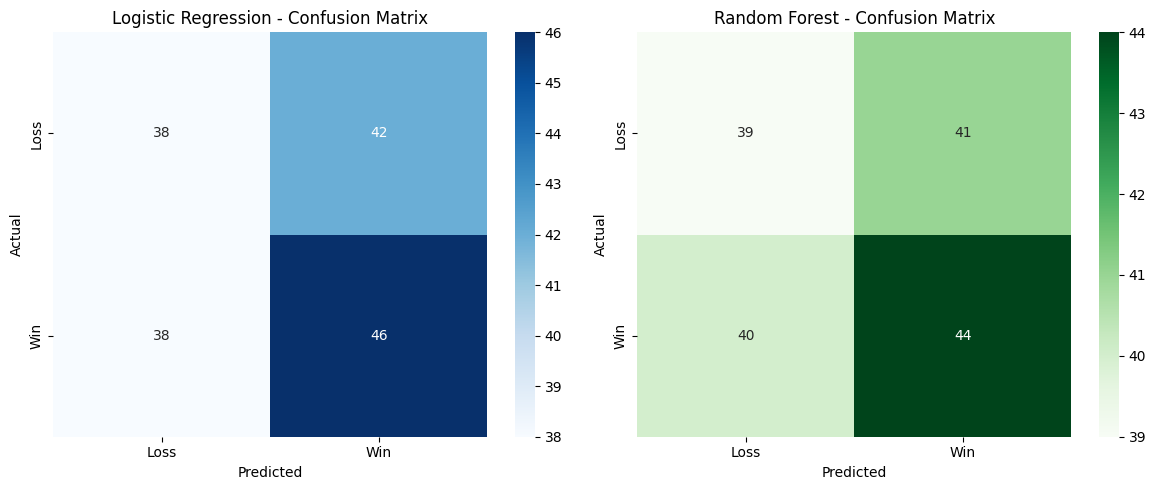

In [23]:
## Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Loss','Win'], yticklabels=['Loss','Win'])
axes[0].set_title('Logistic Regression - Confusion Matrix')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Loss','Win'], yticklabels=['Loss','Win'])
axes[1].set_title('Random Forest - Confusion Matrix')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [24]:
## Full classification reports
print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, target_names=['Loss','Win']))

print("\n=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=['Loss','Win']))

=== Logistic Regression ===
              precision    recall  f1-score   support

        Loss       0.50      0.47      0.49        80
         Win       0.52      0.55      0.53        84

    accuracy                           0.51       164
   macro avg       0.51      0.51      0.51       164
weighted avg       0.51      0.51      0.51       164


=== Random Forest ===
              precision    recall  f1-score   support

        Loss       0.49      0.49      0.49        80
         Win       0.52      0.52      0.52        84

    accuracy                           0.51       164
   macro avg       0.51      0.51      0.51       164
weighted avg       0.51      0.51      0.51       164



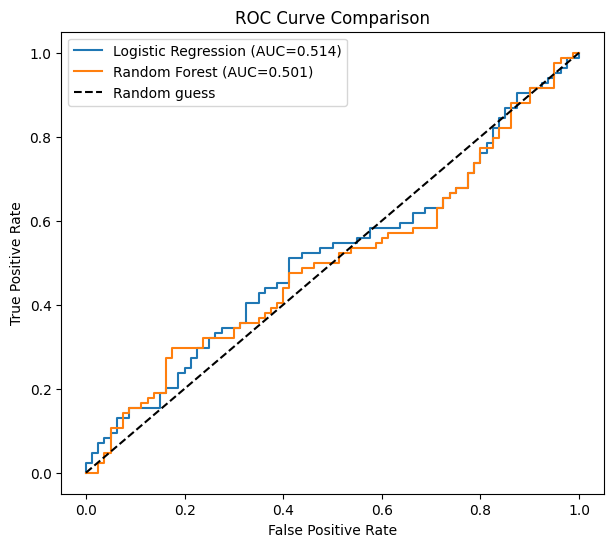

In [25]:
## ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(7,6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={roc_auc_score(y_test, y_prob_lr):.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_score(y_test, y_prob_rf):.3f})')
plt.plot([0,1],[0,1],'k--', label='Random guess')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

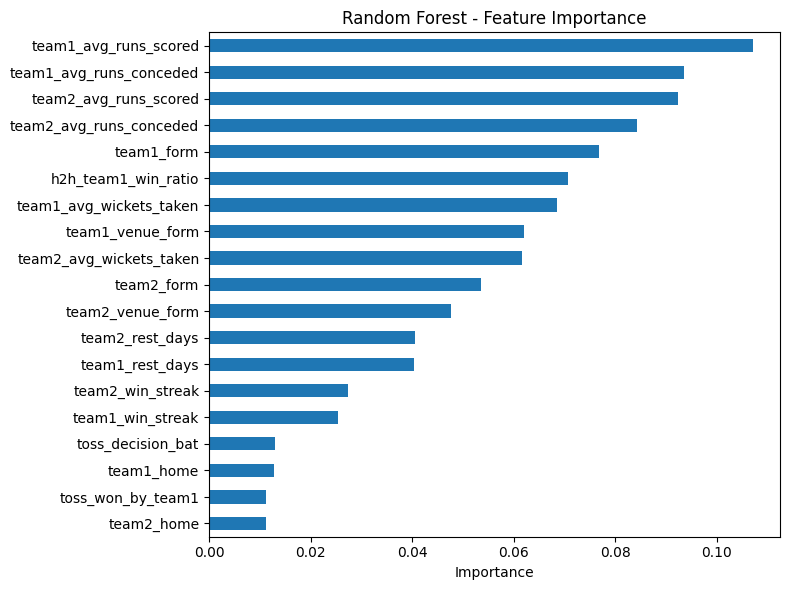

team1_avg_runs_scored      0.107106
team1_avg_runs_conceded    0.093477
team2_avg_runs_scored      0.092456
team2_avg_runs_conceded    0.084353
team1_form                 0.076841
h2h_team1_win_ratio        0.070764
team1_avg_wickets_taken    0.068621
team1_venue_form           0.061972
team2_avg_wickets_taken    0.061545
team2_form                 0.053500
team2_venue_form           0.047678
team2_rest_days            0.040571
team1_rest_days            0.040376
team2_win_streak           0.027352
team1_win_streak           0.025406
toss_decision_bat          0.012957
team1_home                 0.012694
toss_won_by_team1          0.011205
team2_home                 0.011127
dtype: float64


In [26]:
## Feature importance (Random Forest only — interpretability check)
importances = pd.Series(rf.feature_importances_, index=X_test.columns).sort_values(ascending=False)

plt.figure(figsize=(8,6))
importances.plot(kind='barh')
plt.title('Random Forest - Feature Importance')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(importances)

In [27]:
## Final comparison summary
print("========== FINAL MODEL COMPARISON ==========")
print(results.to_string(index=False))

better_model = results.loc[results['Accuracy'].idxmax(), 'Model']
print(f"\nBetter performing model on test set: {better_model}")

========== FINAL MODEL COMPARISON ==========
              Model  Accuracy  Precision   Recall  F1 Score  ROC-AUC
Logistic Regression  0.512195   0.522727 0.547619  0.534884 0.513542
      Random Forest  0.506098   0.517647 0.523810  0.520710 0.501190

Better performing model on test set: Logistic Regression
